# Day 1 · 电压如何控制光：静态 MZM

**本 notebook 的输出全部是模型计算，不是实验测量。**

学习目标：从 Pockels effect 推到相位，再推到输出光功率，最后理解半波电压和正交偏置。

来源：EEK5103 Lecture 4 (2026)，PDF 第 21–22 页。详细来源和论文区别见 `docs/provenance.md`。论文背景为 Liu et al. (2022), [DOI](https://doi.org/10.1109/LPT.2022.3178214)。本日尚未复现论文频响。

## 1 · 先固定参数、单位和电压定义

$\lambda_0=1550\,\mathrm{nm}$，$n_e=2.2$，$r_{33}=30\,\mathrm{pm/V}$，$d=10\,\mu\mathrm m$，$L=2\,\mathrm{cm}$：全部来自课件第 22 页。

假设均匀电场，重叠系数 $\Gamma=1$。V 是器件电极间隙上的电压，暂时不是信号源面板读数。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Run from the project root or notebooks directory"
sys.path.insert(0, str(ROOT / "src"))
import numpy as np
import pandas as pd
from dataclasses import replace
from IPython.display import display, Image
from tfln_mzm.static import StaticParameters, delta_n, phase_difference, half_wave_voltage, transmission, dc_gap_voltage
p = StaticParameters()
p

StaticParameters(wavelength_m=1.55e-06, n_e=2.2, r33_m_per_v=3e-11, gap_m=1e-05, length_m=0.02, overlap=1.0)

## 2 · 电场改变折射率，相位沿长度积累

$\Delta n_e\simeq-\frac12n_e^3r_{33}\Gamma V/d$，$\Delta\phi=2\pi L\Delta n_e/\lambda_0$。

正 V 对应 +z 电场，因此相移为负。半波电压取使 $|\Delta\phi|=\pi$ 的正值：

$$V_\pi=\frac{\lambda_0d}{n_e^3r_{33}\Gamma L}.$$

先手算 $|\Delta n|=\lambda_0/(2L)$。下面打印的结果应为 $3.875\times10^{-5}$ 和约 $2.426\,\mathrm V$。

In [2]:
vpi = half_wave_voltage(p)
print(f"Single-arm Vpi = {vpi:.9f} V")
print(f"Delta n at Vpi = {float(delta_n(vpi, p)):.9e}")
print(f"Phase at Vpi / pi = {float(phase_difference(vpi, p)/np.pi):.6f}")
print(f"Vpi L = {vpi*p.length_m*100:.6f} V cm")
assert np.isclose(abs(delta_n(vpi,p)), 3.875e-5, rtol=1e-12)

Single-arm Vpi = 2.426120711 V
Delta n at Vpi = -3.875000000e-05
Phase at Vpi / pi = -1.000000
Vpi L = 4.852241 V cm


## 3 · 干涉把相位变为光功率

$$T=\frac{1+\cos(\phi_b+\Delta\phi)}2.$$

选择零相位差为亮端口，另一端口功率为 $1-T$。两臂等损耗且分束器理想时，两个端口功率之和为输入功率。

正交偏置 $\phi_b=\pi/2$ 的小信号斜率幅度最大。按当前相移符号，$T\simeq1/2+\pi V/(2V_\pi)$。下面生成完整曲线并对比局部直线。

{
  "provenance": "simulation_from_lecture_parameters",
  "parameters_SI": {
    "wavelength_m": 1.55e-06,
    "n_e": 2.2,
    "r33_m_per_v": 3e-11,
    "gap_m": 1e-05,
    "length_m": 0.02,
    "overlap": 1.0
  },
  "single_arm_Vpi_V": 2.4261207112446774,
  "push_pull_gap_Vpi_V": 1.2130603556223387,
  "delta_n_at_single_arm_Vpi": -3.875e-05,
  "single_arm_VpiL_V_cm": 4.852241422489355,
  "quadrature_slope_per_V": 0.6474518433953057,
  "boundary": "Ideal balanced lossless static model, no traveling-wave or device-field solution"
}


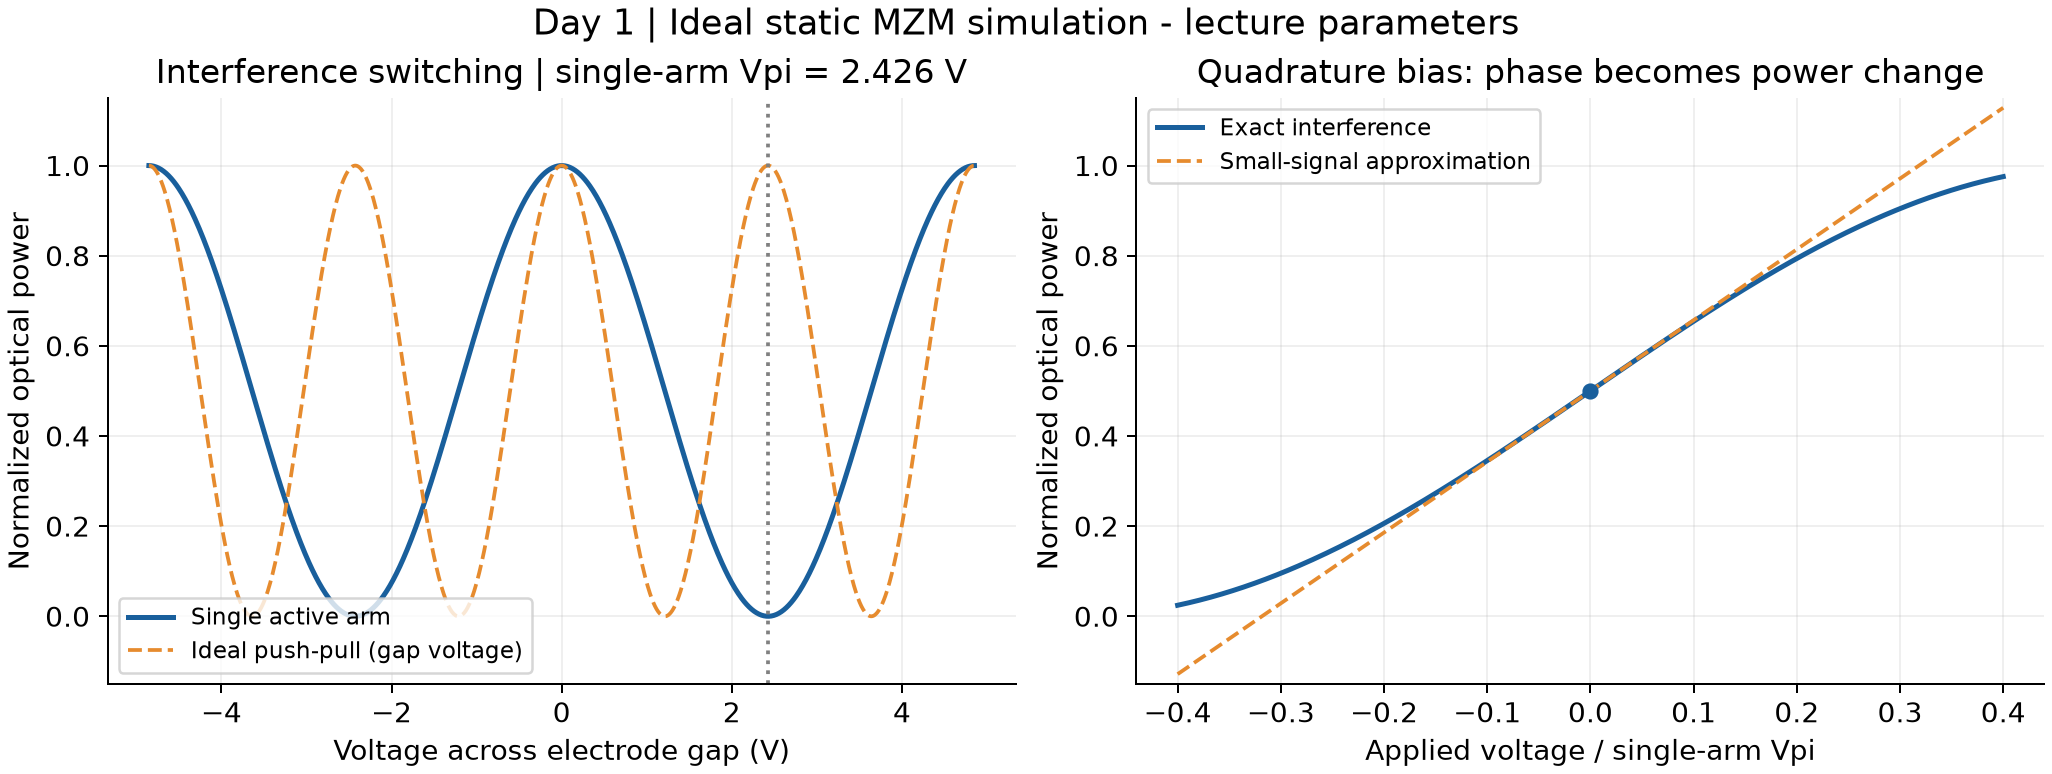

In [3]:
import runpy
runpy.run_path(str(ROOT / "scripts/run_day01.py"), run_name="__main__")
display(Image(filename=str(ROOT / "figures/day01_static_mzm.png")))

**读图：** 左图蓝线在一个 Vpi 内从亮变暗，两个 Vpi 后回到亮。橙线是“两臂受等大反向电场”的理想推挽扩展，按每个间隙电压定义相位变化加倍。右图说明小信号近似只在正交点附近可靠。

这不是论文器件的静态拟合。论文 Fig.5 的 2.7 V 是作者对 6 mm 器件的测量，几何和驱动定义不同。

In [4]:
switching = pd.DataFrame({"V / Vpi": [0, 1, 2], "T": transmission(np.array([0,1,2])*vpi, p)})
display(switching)
phi = phase_difference(np.linspace(-5, 5, 101), p)
bright = np.abs((1+np.exp(1j*phi))/2)**2
dark = np.abs((1-np.exp(1j*phi))/2)**2
print("Max power-conservation error:", np.max(np.abs(bright+dark-1)))
assert np.allclose(bright+dark, 1)

,V / Vpi,T
0,0,1.0
1,1,0.0
2,2,1.0


Max power-conservation error: 4.440892098500626e-16


## 4 · 学会分辨器件电压和电源电压

若信号源开路幅度 $V_g=1$ V，源阻抗 $Z_g=50\,\Omega$，理想无串联电阻的线在 DC 下给出：

$$V_{gap}=V_g\frac{Z_L}{Z_g+Z_L}.$$

低阻终端减少低频电压。后续“归一化频响更平坦”可能以低频驱动下降为代价。此表是理论极限，不是 Figure 3 数字化数据。

In [5]:
loads = [20, 40, 50, 80, np.inf]
display(pd.DataFrame({"ZL (ohm)": loads, "Vgap (V), Vg=1 V": dc_gap_voltage(1, loads), "type": "derived DC limit"}))

,ZL (ohm),"Vgap (V), Vg=1 V",type
0,20.0,0.285714,derived DC limit
1,40.0,0.444444,derived DC limit
2,50.0,0.500000,derived DC limit
3,80.0,0.615385,derived DC limit
4,inf,1.000000,derived DC limit


## 5 · 先预测，再修改参数

把长度减半会怎样？相位累积减半，所以需要两倍电压。

把间距加倍会怎样？场强减半，所以需要两倍电压。

将下面的 `length_m` 改成 0.01 或 0.04，先预测再运行。这里研究静态效率；更长器件的 RF 带宽可能反而降低，要到行波模型才可回答。

In [6]:
trial = replace(p, length_m=0.01)
print("Original Vpi (V):", half_wave_voltage(p))
print("Trial Vpi (V):", half_wave_voltage(trial))
print("Ideal push-pull gap Vpi (V):", half_wave_voltage(p, "push_pull"))

Original Vpi (V): 2.4261207112446774
Trial Vpi (V): 4.852241422489355
Ideal push-pull gap Vpi (V): 1.2130603556223387


## 今日边界与下一步

本模型未包含 RF 损耗、反射、速度失配、有限消光比和真实模场分布，不能预测带宽。所有曲线和数据为 simulation。

验收：能解释半波电压；能分清单臂和推挽的电压约定；知道正交点为什么适合小信号；知道 Vg 不总等于 Vgap。

下一天将从论文 Fig.1(c) 的等效电路核对公式 (1)–(4)，再实现频率相关的相干平均电压。